#Analisis exploratorio de los datos de satelites Starlink extraidos de la API de Space-X. Hay una relación entre los parametros de orbita y el tiempo que un satelite permanece en orbita / la salida del orbite de un satelite?

In [2]:
#import libraries

import pandas as pd
import numpy as np
import os
import requests
import datetime
import matplotlib.pyplot as plt
from matplotlib import ticker

import seaborn as sns
sns.set()


import warnings
warnings.filterwarnings("ignore")

In [99]:
#save URL for API call and the output from the API

url_starlink_sats = 'https://api.spacexdata.com/v4/starlink'
res_starlink_sats = requests.get(url = url_starlink_sats)
satellites = res_starlink_sats.json()

In [5]:
satellites

[{'spaceTrack': {'CCSDS_OMM_VERS': '2.0',
   'COMMENT': 'GENERATED VIA SPACE-TRACK.ORG API',
   'CREATION_DATE': '2020-10-13T04:16:08',
   'ORIGINATOR': '18 SPCS',
   'OBJECT_NAME': 'STARLINK-30',
   'OBJECT_ID': '2019-029K',
   'CENTER_NAME': 'EARTH',
   'REF_FRAME': 'TEME',
   'TIME_SYSTEM': 'UTC',
   'MEAN_ELEMENT_THEORY': 'SGP4',
   'EPOCH': '2020-10-13T02:56:59.566560',
   'MEAN_MOTION': 16.43170483,
   'ECCENTRICITY': 0.0003711,
   'INCLINATION': 52.9708,
   'RA_OF_ASC_NODE': 332.0356,
   'ARG_OF_PERICENTER': 120.7278,
   'MEAN_ANOMALY': 242.0157,
   'EPHEMERIS_TYPE': 0,
   'CLASSIFICATION_TYPE': 'U',
   'NORAD_CAT_ID': 44244,
   'ELEMENT_SET_NO': 999,
   'REV_AT_EPOCH': 7775,
   'BSTAR': 0.0022139,
   'MEAN_MOTION_DOT': 0.47180237,
   'MEAN_MOTION_DDOT': 1.2426e-05,
   'SEMIMAJOR_AXIS': 6535.519,
   'PERIOD': 87.635,
   'APOAPSIS': 159.809,
   'PERIAPSIS': 154.958,
   'OBJECT_TYPE': 'PAYLOAD',
   'RCS_SIZE': 'LARGE',
   'COUNTRY_CODE': 'US',
   'LAUNCH_DATE': '2019-05-24',
   'S

In [100]:
#convert the output from the API into a dataframe
df = pd.DataFrame(satellites)
# The SpaceTrack data is nested inside each satellite JSON. Unnesting the spacetrack data

if 'spaceTrack' in df.columns:
    # Extract the nested spaceTrack dictionaries into separate columns
    space_track_df = pd.json_normalize(df['spaceTrack'])
    
    # Drop the original spaceTrack column 
    df = df.drop('spaceTrack', axis=1)
    
    # Combine the two dataframes
    df = pd.concat([df, space_track_df], axis=1)

# Now I have a DataFrame with each satellite as a row and each key from JSON as a column

df

,launch,version,height_km,latitude,longitude,velocity_kms,id,CCSDS_OMM_VERS,COMMENT,CREATION_DATE,...,COUNTRY_CODE,LAUNCH_DATE,SITE,DECAY_DATE,DECAYED,FILE,GP_ID,TLE_LINE0,TLE_LINE1,TLE_LINE2
0,5eb87d30ffd86e000604b378,v0.9,NaN,NaN,NaN,NaN,5eed770f096e59000698560d,2.0,GENERATED VIA SPACE-TRACK.ORG API,2020-10-13T04:16:08,...,US,2019-05-24,AFETR,2020-10-13,1,2850561,163365918,0 STARLINK-30,1 44244U 19029K 20287.12291165 .47180237 1...,2 44244 52.9708 332.0356 0003711 120.7278 242...
1,5eb87d30ffd86e000604b378,v0.9,NaN,NaN,NaN,NaN,5eed770f096e59000698560e,2.0,GENERATED VIA SPACE-TRACK.ORG API,2020-09-28T19:26:08,...,US,2019-05-24,AFETR,2020-09-29,1,2837086,162391575,0 STARLINK-74,1 44293U 19029BL 20272.77440637 .11359350 1...,2 44293 52.9971 48.1405 0002076 323.1313 37...
2,5eb87d30ffd86e000604b378,v0.9,NaN,NaN,NaN,NaN,5eed770f096e59000698560f,2.0,GENERATED VIA SPACE-TRACK.ORG API,2020-10-13T17:46:09,...,US,2019-05-24,AFETR,2020-10-13,1,2851295,163381397,0 STARLINK-29,1 44243U 19029J 20287.71504568 .11982673 1...,2 44243 52.9786 228.8138 0008105 330.1078 31...
3,5eb87d30ffd86e000604b378,v0.9,NaN,NaN,NaN,NaN,5eed770f096e590006985610,2.0,GENERATED VIA SPACE-TRACK.ORG API,2021-09-26T14:36:11,...,US,2019-05-24,AFETR,2021-09-26,1,3129087,185524941,0 STARLINK-76,1 44287U 19029BE 21269.58650490 .32671130 1...,2 44287 52.9578 116.7260 0003663 96.3451 319...
4,5eb87d30ffd86e000604b378,v0.9,NaN,NaN,NaN,NaN,5eed770f096e590006985611,2.0,GENERATED VIA SPACE-TRACK.ORG API,2020-09-02T18:57:38,...,US,2019-05-24,AFETR,2020-09-02,1,2813120,160599026,0 STARLINK-23,1 44237U 19029C 20246.24351608 +.23336896 +1...,2 44237 052.9945 186.9776 0004551 271.9057 198...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3521,None,None,355.305350,44.268273,137.300802,7.700996,63655b77358d5951a1c69dd0,2.0,GENERATED VIA SPACE-TRACK.ORG API,2022-11-30T17:18:05,...,US,2022-10-28,AFWTR,None,0,3675646,219177338,0 STARLINK-5186,1 54177U 22141W 22334.58335648 .00048875 0...,2 54177 53.2167 337.9278 0003831 6.8795 344...
3522,None,None,353.712986,33.722400,153.947639,7.700405,63655b77358d5951a1c69dfa,2.0,GENERATED VIA SPACE-TRACK.ORG API,2022-11-30T17:18:05,...,US,2022-10-28,AFWTR,None,0,3675646,219178207,0 STARLINK-5205,1 54202U 22141AX 22334.58335648 -.00044287 0...,2 54202 53.2156 337.8864 0003705 4.5467 3...
3523,None,None,355.632656,44.561516,136.668403,7.700673,63655b77358d5951a1c69e37,2.0,GENERATED VIA SPACE-TRACK.ORG API,2022-11-30T17:18:05,...,US,2022-10-28,AFWTR,None,0,3675646,219177167,0 STARLINK-5117,1 54172U 22141R 22334.58335648 -.00074020 0...,2 54172 53.2159 337.9243 0004424 3.2523 347...
3524,None,None,354.996912,40.755340,143.873451,7.700481,63655b77358d5951a1c69e39,2.0,GENERATED VIA SPACE-TRACK.ORG API,2022-11-30T17:18:05,...,US,2022-10-28,AFWTR,None,0,3675646,219177524,0 STARLINK-5162,1 54184U 22141AD 22334.58335648 -.00088576 0...,2 54184 53.2152 337.9079 0004143 1.3558 356...


In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3526 entries, 0 to 3525
Data columns (total 49 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   launch               3215 non-null   object        
 1   version              3215 non-null   object        
 2   height_km            3268 non-null   float64       
 3   latitude             3268 non-null   float64       
 4   longitude            3268 non-null   float64       
 5   velocity_kms         3268 non-null   float64       
 6   id                   3526 non-null   object        
 7   CCSDS_OMM_VERS       3526 non-null   object        
 8   COMMENT              3526 non-null   object        
 9   CREATION_DATE        3526 non-null   object        
 10  ORIGINATOR           3526 non-null   object        
 11  OBJECT_NAME          3526 non-null   object        
 12  OBJECT_ID            3526 non-null   object        
 13  CENTER_NAME          3526 non-nul

In [ ]:
#backfill NaNs in Site so I can use it in feature engineering
df['SITE']=df['SITE'].bfill()

In [120]:
# Create the 'SITE_NUM' numerical column for Air base where satelite is launched from using np.where: 0- West Vandenberg, Santa Barbara,CA, 1- East, Cape Cnaveral
df['SITE_NUM'] = np.where(df['SITE'] == 'AFWTR', 0, 1)

In [87]:
count_west = (df['SITE_NUM'] == 0).sum()
print(count_west)

497


In [88]:
count_east = df['SITE_NUM'].value_counts().get(1, 0)
print(count_east)

3029


In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3526 entries, 0 to 3525
Data columns (total 50 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   launch               3215 non-null   object        
 1   version              3215 non-null   object        
 2   height_km            3268 non-null   float64       
 3   latitude             3268 non-null   float64       
 4   longitude            3268 non-null   float64       
 5   velocity_kms         3268 non-null   float64       
 6   id                   3526 non-null   object        
 7   CCSDS_OMM_VERS       3526 non-null   object        
 8   COMMENT              3526 non-null   object        
 9   CREATION_DATE        3526 non-null   object        
 10  ORIGINATOR           3526 non-null   object        
 11  OBJECT_NAME          3526 non-null   object        
 12  OBJECT_ID            3526 non-null   object        
 13  CENTER_NAME          3526 non-nul

In [80]:
df.tail()

,launch,version,height_km,latitude,longitude,velocity_kms,id,CCSDS_OMM_VERS,COMMENT,CREATION_DATE,...,SITE,DECAY_DATE,DECAYED,FILE,GP_ID,TLE_LINE0,TLE_LINE1,TLE_LINE2,DAYS_ORBIT,SITE_NUM
3521,None,None,355.305350,44.268273,137.300802,7.700996,63655b77358d5951a1c69dd0,2.0,GENERATED VIA SPACE-TRACK.ORG API,2022-11-30T17:18:05,...,AFWTR,NaT,0,3675646,219177338,0 STARLINK-5186,1 54177U 22141W 22334.58335648 .00048875 0...,2 54177 53.2167 337.9278 0003831 6.8795 344...,869.0,0
3522,None,None,353.712986,33.722400,153.947639,7.700405,63655b77358d5951a1c69dfa,2.0,GENERATED VIA SPACE-TRACK.ORG API,2022-11-30T17:18:05,...,AFWTR,NaT,0,3675646,219178207,0 STARLINK-5205,1 54202U 22141AX 22334.58335648 -.00044287 0...,2 54202 53.2156 337.8864 0003705 4.5467 3...,869.0,0
3523,None,None,355.632656,44.561516,136.668403,7.700673,63655b77358d5951a1c69e37,2.0,GENERATED VIA SPACE-TRACK.ORG API,2022-11-30T17:18:05,...,AFWTR,NaT,0,3675646,219177167,0 STARLINK-5117,1 54172U 22141R 22334.58335648 -.00074020 0...,2 54172 53.2159 337.9243 0004424 3.2523 347...,869.0,0
3524,None,None,354.996912,40.755340,143.873451,7.700481,63655b77358d5951a1c69e39,2.0,GENERATED VIA SPACE-TRACK.ORG API,2022-11-30T17:18:05,...,AFWTR,NaT,0,3675646,219177524,0 STARLINK-5162,1 54184U 22141AD 22334.58335648 -.00088576 0...,2 54184 53.2152 337.9079 0004143 1.3558 356...,869.0,0
3525,None,None,355.396192,44.069184,137.731004,7.700827,63655b77358d5951a1c69e41,2.0,GENERATED VIA SPACE-TRACK.ORG API,2022-11-30T17:18:05,...,AFWTR,NaT,0,3675646,219178033,0 STARLINK-5122,1 54179U 22141Y 22334.58335648 -.00060135 0...,2 54179 53.2161 337.9252 0003828 2.9089 349...,869.0,0


In [ ]:
#check how many NaN in each column
df.isna().sum()

launch                  311
version                 311
height_km               258
latitude                258
longitude               258
velocity_kms            258
id                        0
CCSDS_OMM_VERS            0
COMMENT                   0
CREATION_DATE             0
ORIGINATOR                0
OBJECT_NAME               0
OBJECT_ID                 0
CENTER_NAME               0
REF_FRAME                 0
TIME_SYSTEM               0
MEAN_ELEMENT_THEORY       0
EPOCH                     0
MEAN_MOTION               0
ECCENTRICITY              0
INCLINATION               0
RA_OF_ASC_NODE            0
ARG_OF_PERICENTER         0
MEAN_ANOMALY              0
EPHEMERIS_TYPE            0
CLASSIFICATION_TYPE       0
NORAD_CAT_ID              0
ELEMENT_SET_NO            0
REV_AT_EPOCH              0
BSTAR                     0
MEAN_MOTION_DOT           0
MEAN_MOTION_DDOT          0
SEMIMAJOR_AXIS            0
PERIOD                    0
APOAPSIS                  0
PERIAPSIS           

In [ ]:
#There's missing values in 'LAUNCH_DATE' which I'm using for feature engineering
df.loc[df['LAUNCH_DATE'].isnull()]

,launch,version,height_km,latitude,longitude,velocity_kms,id,CCSDS_OMM_VERS,COMMENT,CREATION_DATE,...,SITE,DECAY_DATE,DECAYED,FILE,GP_ID,TLE_LINE0,TLE_LINE1,TLE_LINE2,DAYS_ORBIT,SITE_NUM
2042,None,None,NaN,NaN,NaN,NaN,620014f3a8973c1694aa40bd,2.0,GENERATED VIA SPACE-TRACK.ORG API,2022-02-06T06:56:12,...,AFETR,2022-02-07,1,3293121,195380770,0 STARLINK-3XXX,1 51459U 22010D 22037.23001983 .03586192 1...,2 51459 53.2230 161.6012 0071354 169.6697 190...,NaN,1
2043,None,None,NaN,NaN,NaN,NaN,620014f3a8973c1694aa40be,2.0,GENERATED VIA SPACE-TRACK.ORG API,2022-02-06T00:46:11,...,AFETR,2022-02-08,1,3293008,195378552,0 STARLINK-3XXX,1 51457U 22010B 22037.00001157 -.00956184 3...,2 51457 53.2173 162.8217 0078778 164.2324 275...,NaN,1
2044,None,None,NaN,NaN,NaN,NaN,620014f3a8973c1694aa40ce,2.0,GENERATED VIA SPACE-TRACK.ORG API,2022-02-06T00:46:11,...,AFETR,2022-02-06,1,3293005,195378555,0 STARLINK-3XXX,1 51458U 22010C 22037.00001157 -.00957341 3...,2 51458 53.2173 162.8262 0079772 163.8403 273...,NaN,1
2045,None,None,NaN,NaN,NaN,NaN,620190a6a8973c1694b4fcda,2.0,GENERATED VIA SPACE-TRACK.ORG API,2022-02-06T18:07:45,...,AFETR,2022-02-06,1,3293555,195415050,0 STARLINK-3XXX,1 51456U 22010A 22037.59202951 .49730979 1...,2 51456 53.2082 159.5480 0015581 174.4115 185...,NaN,1
2046,None,None,NaN,NaN,NaN,NaN,6204097da8973c1694c6a3d9,2.0,GENERATED VIA SPACE-TRACK.ORG API,2022-02-09T01:36:12,...,AFETR,2022-02-09,1,3295469,195581643,0 STARLINK-3XXX,1 51466U 22010L 22039.46449989 -.00003746 1...,2 51466 53.2042 149.8871 0044415 182.9144 177...,NaN,1


In [ ]:
#missing launch dates are all for decayed satelites. I will fill DAYS_ORBIT with median of this value for decayed satelites
# Calculate the median DAYS_ORBIT for decayed satellites
decayed_median_days = df[df['DECAYED'] == 1]['DAYS_ORBIT'].median()

# Fill the missing values in DAYS_ORBIT with this median
df['DAYS_ORBIT'] = df['DAYS_ORBIT'].fillna(decayed_median_days)

In [102]:
df['RCS_SIZE']=df['RCS_SIZE'].bfill()


In [105]:
# Create the 'RCS_SIZE_NUM' numerical column 0- MEDIUM 1- LARGE
df['RCS_SIZE_NUM']= np.where(df['RCS_SIZE'] == 'MEDIUM', 0, 1)
df['RCS_SIZE_NUM'].unique()

array([1, 0])

In [107]:
count_medium = (df['RCS_SIZE_NUM'] == 0).sum()
print(count_medium)

69


In [108]:
count_large = (df['RCS_SIZE_NUM'] == 1).sum()
print(count_large)

3457


In [18]:
df[['DECAY_DATE','DECAYED','LAUNCH_DATE']]

,DECAY_DATE,DECAYED,LAUNCH_DATE
0,2020-10-13,1,2019-05-24
1,2020-09-29,1,2019-05-24
2,2020-10-13,1,2019-05-24
3,2021-09-26,1,2019-05-24
4,2020-09-02,1,2019-05-24
...,...,...,...
3521,None,0,2022-10-28
3522,None,0,2022-10-28
3523,None,0,2022-10-28
3524,None,0,2022-10-28


In [ ]:
#I want to create a column for days in orbit. First I need to make sure that decay_date and launch_date are actually correct data types
from datetime import datetime

# Convert date columns to datetime
df['LAUNCH_DATE'] = pd.to_datetime(df['LAUNCH_DATE'])

# Convert DECAY_DATE to datetime, but keep NaN values as NaN
df['DECAY_DATE'] = pd.to_datetime(df['DECAY_DATE'], errors='coerce')

# Get current date for satellites still in orbit
current_date = pd.Timestamp.now().floor('D')  # Floor to remove time component

# Calculate days in orbit
# For decayed satellites: DECAY_DATE - LAUNCH_DATE
# For active satellites: current_date - LAUNCH_DATE
df['DAYS_ORBIT'] = df.apply(
    lambda row: (row['DECAY_DATE'] - row['LAUNCH_DATE']).days if pd.notna(row['DECAY_DATE']) 
    else (current_date - row['LAUNCH_DATE']).days, 
    axis=1
)

In [15]:
df[['DAYS_ORBIT','BSTAR','LAUNCH_DATE']].describe()

,DAYS_ORBIT,BSTAR,LAUNCH_DATE
count,3521.000000,3526.000000,3521
mean,1228.152798,-0.001121,2021-08-03 12:07:58.500425984
min,7.000000,-0.075593,2018-02-22 00:00:00
25%,965.000000,0.000004,2020-10-24 00:00:00
50%,1164.000000,0.000062,2021-09-14 00:00:00
75%,1500.000000,0.000139,2022-06-17 00:00:00
max,1951.000000,0.008197,2022-10-28 00:00:00
std,383.951834,0.007950,NaN


In [23]:
df[['DECAY_DATE','DECAYED','LAUNCH_DATE', 'DAYS_ORBIT']]

,DECAY_DATE,DECAYED,LAUNCH_DATE,DAYS_ORBIT
0,2020-10-13,1,2019-05-24,508.0
1,2020-09-29,1,2019-05-24,494.0
2,2020-10-13,1,2019-05-24,508.0
3,2021-09-26,1,2019-05-24,856.0
4,2020-09-02,1,2019-05-24,467.0
...,...,...,...,...
3521,NaT,0,2022-10-28,866.0
3522,NaT,0,2022-10-28,866.0
3523,NaT,0,2022-10-28,866.0
3524,NaT,0,2022-10-28,866.0


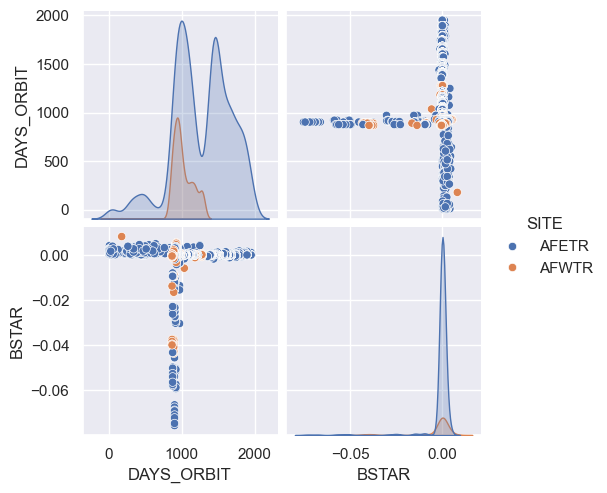

In [ ]:
#pairplot basic relationships

sns.pairplot(df[['DAYS_ORBIT','BSTAR','SITE']],hue='SITE',diag_kind='kde')



<Axes: xlabel='DAYS_ORBIT', ylabel='Count'>

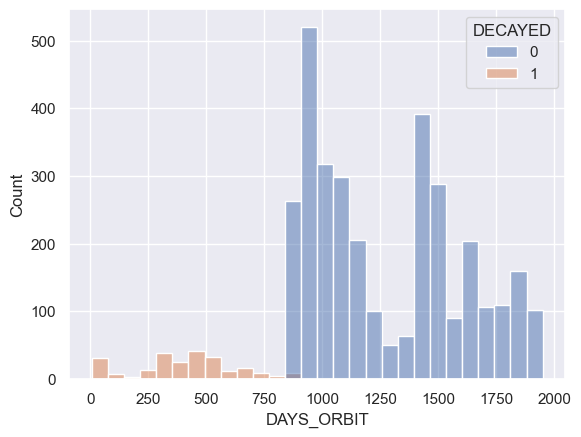

In [22]:
sns.histplot(data=df, x='DAYS_ORBIT', hue='DECAYED')

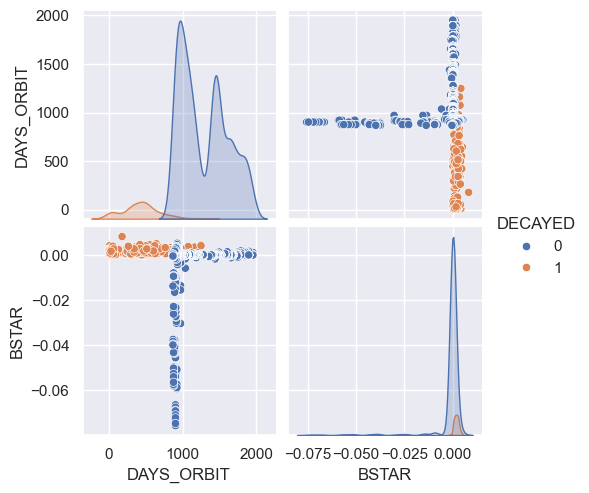

In [ ]:
sns.pairplot(df[['DAYS_ORBIT','BSTAR','DECAYED']],hue='DECAYED',diag_kind='kde')

In [122]:
#select numeric columns

df_num=df.select_dtypes('number')

In [123]:
df_num.describe()

,height_km,latitude,longitude,velocity_kms,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,...,MEAN_MOTION_DDOT,SEMIMAJOR_AXIS,PERIOD,APOAPSIS,PERIAPSIS,DECAYED,FILE,GP_ID,RCS_SIZE_NUM,SITE_NUM
count,3268.000000,3268.000000,3268.000000,3268.000000,3526.000000,3526.000000,3526.000000,3526.000000,3526.000000,3526.000000,...,3526.000000,3526.000000,3526.000000,3526.000000,3526.000000,3526.000000,3.526000e+03,3.526000e+03,3526.000000,3526.000000
mean,539.588682,1.321539,2.248772,7.594950,15.205655,0.000268,55.884862,175.859229,76.763091,274.190037,...,0.000001,6884.325872,94.752176,508.013938,504.367812,0.073171,3.639188e+06,2.167925e+08,0.980431,0.859047
std,45.941995,37.061888,102.982183,0.026316,0.362179,0.000361,10.410713,102.320278,68.748335,75.839360,...,0.000012,103.933078,2.124299,102.701246,105.203804,0.260453,1.464317e+05,9.705201e+06,0.138533,0.348022
min,303.137599,-82.237072,-179.933614,7.561740,14.980207,0.000022,52.942000,0.079000,0.049500,0.214500,...,0.000000,6499.858000,86.919000,125.504000,99.974000,0.000000,2.706890e+06,1.491550e+08,0.000000,0.000000
25%,543.024058,-32.992599,-86.384518,7.582612,15.063925,0.000161,53.054900,90.177325,43.042975,282.043250,...,0.000000,6917.882000,95.438000,541.123000,537.861000,0.000000,3.674952e+06,2.191366e+08,1.000000,1.000000
50%,549.031323,2.244397,1.907842,7.591027,15.088160,0.000193,53.212650,174.155950,57.935750,299.933700,...,0.000000,6917.954000,95.439000,541.971500,538.717500,0.000000,3.675646e+06,2.191735e+08,1.000000,1.000000
75%,556.617742,36.505165,91.000716,7.595025,15.088396,0.000263,53.217600,261.441650,73.161325,315.514475,...,0.000000,6925.371750,95.593000,548.409000,546.105750,0.000000,3.675646e+06,2.191764e+08,1.000000,1.000000
max,595.373243,82.297000,179.973121,7.729005,16.567117,0.007977,97.661600,359.927700,359.907900,359.937300,...,0.000550,6951.150000,96.127000,575.953000,570.256000,1.000000,3.675646e+06,2.191784e+08,1.000000,1.000000


In [38]:
df_num['NORAD_CAT_ID']

0       44244
1       44293
2       44243
3       44287
4       44237
        ...  
3521    54177
3522    54202
3523    54172
3524    54184
3525    54179
Name: NORAD_CAT_ID, Length: 3526, dtype: int64

In [124]:
list(df_num.columns.values)

['height_km',
 'latitude',
 'longitude',
 'velocity_kms',
 'MEAN_MOTION',
 'ECCENTRICITY',
 'INCLINATION',
 'RA_OF_ASC_NODE',
 'ARG_OF_PERICENTER',
 'MEAN_ANOMALY',
 'EPHEMERIS_TYPE',
 'NORAD_CAT_ID',
 'ELEMENT_SET_NO',
 'REV_AT_EPOCH',
 'BSTAR',
 'MEAN_MOTION_DOT',
 'MEAN_MOTION_DDOT',
 'SEMIMAJOR_AXIS',
 'PERIOD',
 'APOAPSIS',
 'PERIAPSIS',
 'DECAYED',
 'FILE',
 'GP_ID',
 'RCS_SIZE_NUM',
 'SITE_NUM']

In [128]:
#drop GUIDs and variables only available for orbiting satellites such as current velocity and height

df_num=df_num.drop(['FILE',
 'GP_ID', 'NORAD_CAT_ID',
 'ELEMENT_SET_NO', 'latitude',
 'longitude','height_km','velocity_kms'],axis=1)

KeyError: "['height_km', 'velocity_kms'] not found in axis"

In [127]:
df_num=df_num.drop(['height_km','velocity_kms'],axis=1)

In [130]:
df_num=df_num.drop(['latitude','longitude'],axis=1)

In [131]:
df_num.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3526 entries, 0 to 3525
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   MEAN_MOTION        3526 non-null   float64
 1   ECCENTRICITY       3526 non-null   float64
 2   INCLINATION        3526 non-null   float64
 3   RA_OF_ASC_NODE     3526 non-null   float64
 4   ARG_OF_PERICENTER  3526 non-null   float64
 5   MEAN_ANOMALY       3526 non-null   float64
 6   EPHEMERIS_TYPE     3526 non-null   int64  
 7   NORAD_CAT_ID       3526 non-null   int64  
 8   ELEMENT_SET_NO     3526 non-null   int64  
 9   REV_AT_EPOCH       3526 non-null   int64  
 10  BSTAR              3526 non-null   float64
 11  MEAN_MOTION_DOT    3526 non-null   float64
 12  MEAN_MOTION_DDOT   3526 non-null   float64
 13  SEMIMAJOR_AXIS     3526 non-null   float64
 14  PERIOD             3526 non-null   float64
 15  APOAPSIS           3526 non-null   float64
 16  PERIAPSIS          3526 

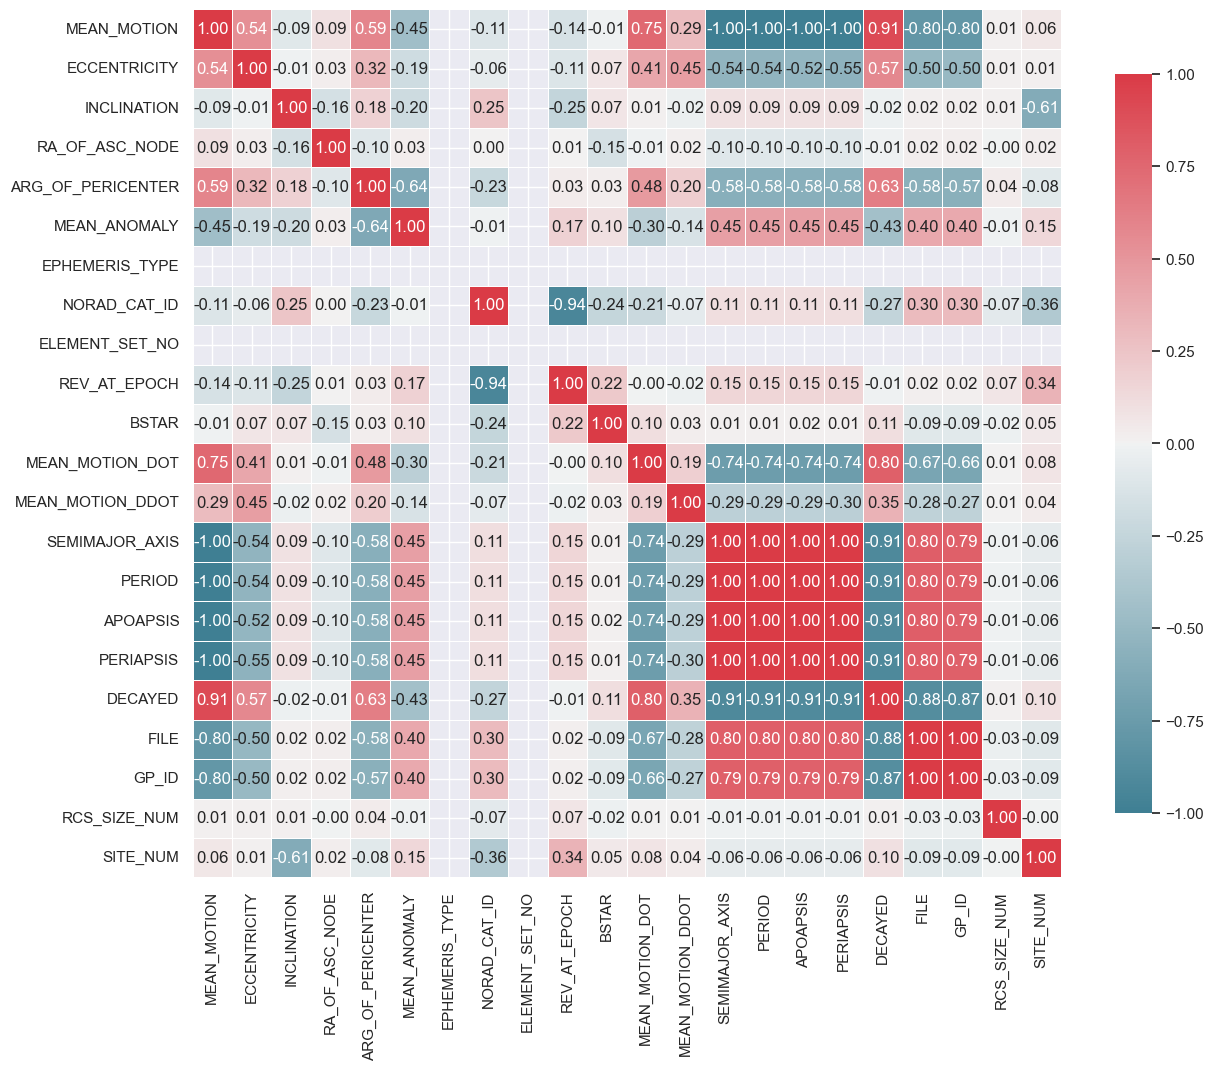

In [132]:
# Calculate the correlation matrix
correlation_matrix = df_num.corr()

# Set up the matplotlib figure
plt.figure(figsize=(14, 12))

# Create a custom colormap with dark red for strong positive correlations
cmap = sns.diverging_palette(220, 10, as_cmap=True)

heatmap = sns.heatmap(
    correlation_matrix,
    cmap=cmap,
    vmax=1.0,
    vmin=-1.0,
    center=0,
    square=True,
    linewidths=.5,
    annot=True,
    fmt=".2f",
    cbar_kws={"shrink": .8}
)
plt.show()

In [133]:
df_num.groupby('DECAYED')[['MEAN_MOTION','REV_AT_EPOCH','MEAN_MOTION_DOT','MEAN_MOTION_DDOT']].agg(['mean','std','count'])

MEAN_MOTION                 REV_AT_EPOCH                     \
               mean       std count         mean          std count   
DECAYED                                                               
0         15.112778  0.151374  3268  6799.387393  4973.929460  3268   
1         16.382098  0.093779   258  6550.399225  3806.803343   258   

        MEAN_MOTION_DOT                 MEAN_MOTION_DDOT                      
                   mean       std count             mean           std count  
DECAYED                                                                       
0              -0.00052  0.002418  3268     1.187974e-08  6.791224e-07  3268  
1               0.28001  0.205820   258     1.616924e-05  4.212369e-05   258

In [134]:
df_neg_drag=df_num[df_num['BSTAR']<0]

In [135]:
df_neg_drag.describe()

,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,NORAD_CAT_ID,ELEMENT_SET_NO,REV_AT_EPOCH,...,MEAN_MOTION_DDOT,SEMIMAJOR_AXIS,PERIOD,APOAPSIS,PERIAPSIS,DECAYED,FILE,GP_ID,RCS_SIZE_NUM,SITE_NUM
count,832.000000,832.000000,832.000000,832.000000,832.000000,832.000000,832.0,832.000000,832.0,832.000000,...,8.320000e+02,832.00000,832.00000,832.000000,832.000000,832.000000,8.320000e+02,8.320000e+02,832.000000,832.000000
mean,15.196896,0.000235,55.065564,197.766909,71.450355,269.381247,0.0,50890.965144,999.0,5242.370192,...,7.298317e-07,6885.81638,94.77846,509.292750,506.070049,0.002404,3.674447e+06,2.191066e+08,0.983173,0.811298
std,0.235888,0.000391,8.539174,102.991907,64.260125,79.427094,0.0,3119.191430,0.0,5032.202013,...,1.487675e-05,69.86903,1.43686,69.237547,70.590922,0.049000,1.874427e+04,1.165687e+06,0.128700,0.391507
min,14.982950,0.000022,53.017700,0.128800,0.049500,0.770400,0.0,44719.000000,999.0,130.000000,...,0.000000e+00,6654.74600,90.04400,329.036000,224.186000,0.000000,3.293005e+06,1.953786e+08,0.000000,0.000000
25%,15.063928,0.000154,53.055700,114.938225,40.489250,271.553175,0.0,48101.250000,999.0,130.000000,...,0.000000e+00,6883.19125,94.72075,506.222500,503.890000,0.000000,3.675646e+06,2.191712e+08,1.000000,1.000000
50%,15.088302,0.000186,53.216400,199.189850,57.538600,297.648850,0.0,52277.500000,999.0,3531.000000,...,0.000000e+00,6917.91000,95.43800,541.541500,538.329000,0.000000,3.675646e+06,2.191748e+08,1.000000,1.000000
75%,15.202605,0.000252,53.217500,289.129250,72.587225,315.369600,0.0,53825.250000,999.0,9258.750000,...,0.000000e+00,6925.37100,95.59300,548.363250,546.043250,0.000000,3.675646e+06,2.191773e+08,1.000000,1.000000
max,15.992102,0.007977,97.659200,359.815600,359.847900,359.937300,0.0,54209.000000,999.0,16967.000000,...,3.037900e-04,6950.30100,96.10900,575.218000,570.256000,1.000000,3.675646e+06,2.191784e+08,1.000000,1.000000


In [136]:
df_pos_drag=df_num[df_num['BSTAR']>=0]

In [137]:
df_pos_drag.describe()

,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,NORAD_CAT_ID,ELEMENT_SET_NO,REV_AT_EPOCH,...,MEAN_MOTION_DDOT,SEMIMAJOR_AXIS,PERIOD,APOAPSIS,PERIAPSIS,DECAYED,FILE,GP_ID,RCS_SIZE_NUM,SITE_NUM
count,2694.000000,2694.000000,2694.000000,2694.000000,2694.000000,2694.000000,2694.0,2694.000000,2694.0,2694.000000,...,2694.000000,2694.000000,2694.000000,2694.000000,2694.000000,2694.000000,2.694000e+03,2.694000e+03,2694.000000,2694.000000
mean,15.208361,0.000278,56.137890,169.093383,78.403847,275.675157,0.0,49326.561247,999.0,7256.402747,...,0.000001,6883.865552,94.744058,507.618997,503.842103,0.095026,3.628299e+06,2.160779e+08,0.979584,0.873794
std,0.393063,0.000350,10.913094,101.176594,70.006336,74.649173,0.0,3077.786534,0.0,4757.104785,...,0.000011,112.392627,2.295531,111.023727,113.791041,0.293305,1.656976e+05,1.098666e+07,0.141444,0.332143
min,14.980207,0.000043,52.942000,0.079000,0.538400,0.214500,0.0,43216.000000,999.0,130.000000,...,0.000000,6499.858000,86.919000,125.504000,99.974000,0.000000,2.706890e+06,1.491550e+08,0.000000,0.000000
25%,15.063925,0.000163,53.054700,81.910850,44.001200,283.362025,0.0,46694.250000,999.0,3099.000000,...,0.000000,6917.888000,95.438000,541.211500,537.955250,0.000000,3.674504e+06,2.191304e+08,1.000000,1.000000
50%,15.064083,0.000196,53.056800,164.998900,58.140700,300.412650,0.0,48464.500000,999.0,7017.500000,...,0.000000,6925.323500,95.592000,548.064500,545.689000,0.000000,3.675646e+06,2.191731e+08,1.000000,1.000000
75%,15.088376,0.000266,53.217800,246.953275,73.296650,315.514475,0.0,52538.500000,999.0,10374.750000,...,0.000000,6925.372000,95.593000,548.415500,546.117000,0.000000,3.675646e+06,2.191760e+08,1.000000,1.000000
max,16.567117,0.007135,97.661600,359.927700,359.907900,359.584000,0.0,54189.000000,999.0,18984.000000,...,0.000550,6951.150000,96.127000,575.953000,570.249000,1.000000,3.675646e+06,2.191783e+08,1.000000,1.000000


In [138]:
df_neg_drag.groupby('DECAYED').count()

,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,NORAD_CAT_ID,ELEMENT_SET_NO,REV_AT_EPOCH,...,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,SEMIMAJOR_AXIS,PERIOD,APOAPSIS,PERIAPSIS,FILE,GP_ID,RCS_SIZE_NUM,SITE_NUM
DECAYED,,,,,,,,,,,,,,,,,,,,,
0,830,830,830,830,830,830,830,830,830,830,...,830,830,830,830,830,830,830,830,830,830
1,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2


In [139]:
df_pos_drag.groupby('DECAYED').count()

,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,NORAD_CAT_ID,ELEMENT_SET_NO,REV_AT_EPOCH,...,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,SEMIMAJOR_AXIS,PERIOD,APOAPSIS,PERIAPSIS,FILE,GP_ID,RCS_SIZE_NUM,SITE_NUM
DECAYED,,,,,,,,,,,,,,,,,,,,,
0,2438,2438,2438,2438,2438,2438,2438,2438,2438,2438,...,2438,2438,2438,2438,2438,2438,2438,2438,2438,2438
1,256,256,256,256,256,256,256,256,256,256,...,256,256,256,256,256,256,256,256,256,256
